In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("data_YesBank_StockPrices.csv")

In [3]:
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


In [4]:
df.shape

(185, 5)

In [5]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    str    
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), str(1)
memory usage: 7.4 KB


In [7]:
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


In [8]:
df.isnull().sum()

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Date         str
Open     float64
High     float64
Low      float64
Close    float64
dtype: object

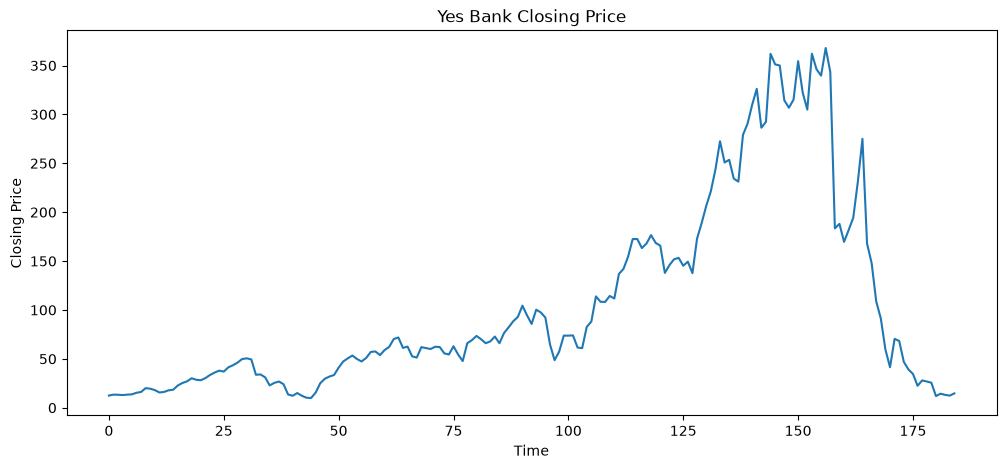

In [11]:
plt.figure(figsize=(12,5))

plt.plot(df["Close"])

plt.title("Yes Bank Closing Price")
plt.xlabel("Time")
plt.ylabel("Closing Price")

plt.show()

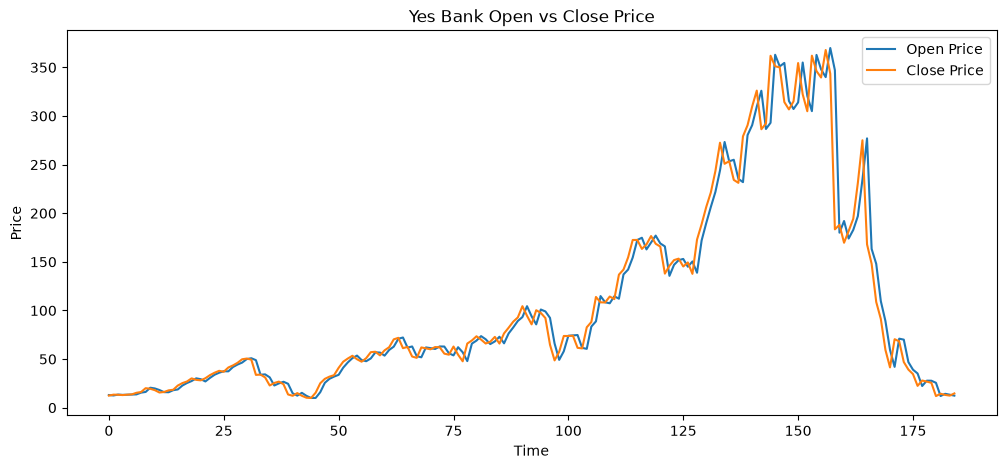

In [12]:
plt.figure(figsize=(12,5))

plt.plot(df["Open"], label="Open Price")
plt.plot(df["Close"], label="Close Price")

plt.title("Yes Bank Open vs Close Price")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()

plt.show()

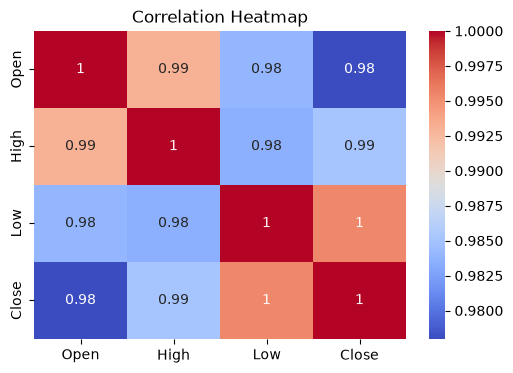

In [13]:
plt.figure(figsize=(6,4))

sns.heatmap(df[["Open","High","Low","Close"]].corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

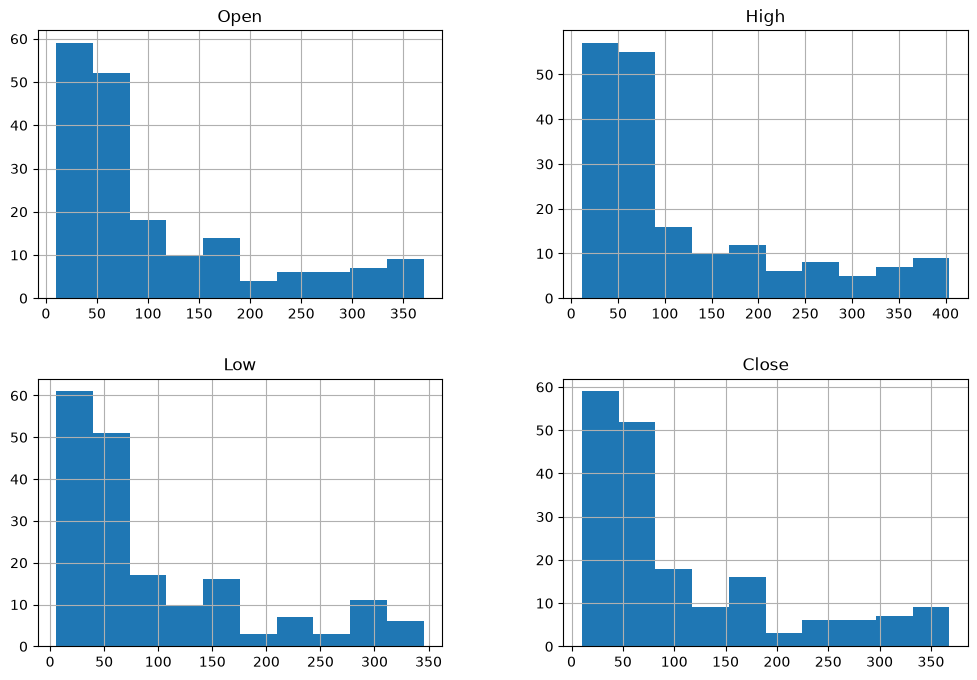

In [14]:
df.hist(figsize=(12,8))

plt.show()

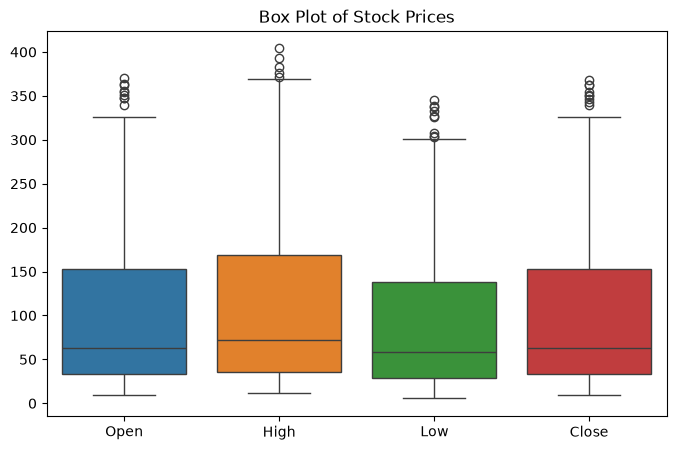

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df[["Open","High","Low","Close"]])

plt.title("Box Plot of Stock Prices")

plt.show()

In [16]:
df["Date"] = pd.to_datetime(df["Date"], format="%b-%y")

In [17]:
df.head()

,Date,Open,High,Low,Close
0,2005-07-01,13.00,14.00,11.25,12.46
1,2005-08-01,12.58,14.88,12.55,13.42
2,2005-09-01,13.48,14.87,12.27,13.30
3,2005-10-01,13.20,14.47,12.40,12.99
4,2005-11-01,13.35,13.88,12.88,13.41


In [18]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

In [19]:
df.head()

,Date,Open,High,Low,Close,Year,Month
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11


In [20]:
X = df[["Open", "High", "Low", "Year", "Month"]]
y = df["Close"]

In [21]:
X.shape, y.shape

((185, 5), (185,))

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [23]:
X_train.shape, X_test.shape

((148, 5), (37, 5))

In [24]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-0.5 , 0.53, 1. , 0.04,-0.21]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Open','High','Low','Year','Month']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-69.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [25]:
y_pred_lr = lr.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("MSE :", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", mean_squared_error(y_test, y_pred_lr) ** 0.5)
print("R2 Score:", r2_score(y_test, y_pred_lr))

MAE : 5.896270669836196
MSE : 84.01889739942405
RMSE: 9.166182269594254
R2 Score: 0.9907046745006219


In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [28]:
y_pred_rf = rf.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("MSE :", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf) ** 0.5)
print("R2 Score:", r2_score(y_test, y_pred_rf))

MAE : 8.567924324324286
MSE : 190.74022543513465
RMSE: 13.8108734493925
R2 Score: 0.9788976940173879


In [30]:
from sklearn.model_selection import GridSearchCV

In [31]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None]
}

In [32]:
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information p

In [33]:
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best Score: 0.9875962595792104


In [34]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("MSE:", mean_squared_error(y_test, y_pred_best))
print("RMSE:", mean_squared_error(y_test, y_pred_best)**0.5)
print("R2 Score:", r2_score(y_test, y_pred_best))

MAE: 8.509766445731412
MSE: 188.58940207324957
RMSE: 13.732785663267652
R2 Score: 0.979135647666617


# **Project Name -**

Yes Bank Stock Price Prediction using Machine Learning



## Project Type -
Regression

## Contribution -
Individual

## Team Members -
Not Applicable (Individual Project)

# **Project Summary -** 
The Yes Bank Stock Price Prediction using Machine Learning project aims to analyze historical stock price data of Yes Bank and develop a machine learning model capable of predicting the future closing price of the stock. Stock price prediction is a challenging task because financial markets are influenced by numerous economic, political, and company-specific factors. However, by analyzing historical trends and identifying patterns in the available data, machine learning algorithms can provide meaningful predictions that assist investors and financial analysts in making informed decisions.

The project began with collecting the historical stock price dataset, which contains features such as Date, Open, High, Low, and Close prices. The dataset was first inspected to understand its structure, identify missing values, verify data types, and check for duplicate records. Proper data preprocessing was performed to ensure that the dataset was clean and suitable for analysis. The Date column was converted into a datetime format, and additional features such as Year and Month were extracted to improve the model’s learning capability.

An extensive Exploratory Data Analysis (EDA) was carried out to understand the characteristics of the dataset. Various visualization techniques such as histograms, correlation heatmaps, box plots, and distribution plots were used to analyze the distribution of stock prices, detect outliers, and study the relationships among different variables. These visualizations provided valuable insights into the behaviour of the stock prices and helped in selecting relevant features for model development.

After completing the data analysis, the dataset was divided into training and testing sets using an 80:20 train-test split. Different machine learning regression techniques were applied to predict the closing stock price. Initially, a Linear Regression model was implemented to establish a baseline prediction model. Later, a Random Forest Regressor was developed to improve prediction accuracy by capturing more complex relationships within the data. Furthermore, GridSearchCV was applied for hyperparameter tuning to determine the optimal model parameters and improve the overall performance of the Random Forest model.

The performance of the developed models was evaluated using standard regression evaluation metrics, including Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. These metrics helped compare the effectiveness of different models and determine how accurately the predicted values matched the actual closing prices. The final model achieved a high prediction accuracy, demonstrating the effectiveness of machine learning techniques in stock price forecasting.

Overall, this project provided practical experience in data preprocessing, exploratory data analysis, feature engineering, machine learning model development, hyperparameter optimization, and model evaluation using Python libraries such as Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn. The project demonstrates how historical financial data can be analyzed and utilized to build predictive models that support data-driven investment decisions. It also highlights the importance of selecting appropriate algorithms and evaluation methods to develop reliable and accurate predictive systems.

# **GitHub Link -**

https://github.com/tanimnaha/YesBank-Stock-Price-Prediction.git

# **Problem Statement**


The objective of this project is to analyze the historical stock price data of Yes Bank and develop a machine learning model capable of accurately predicting future closing stock prices. The project focuses on understanding stock price trends, identifying key influencing factors, and providing data-driven insights for better investment decisions.

#### **Define Your Business Objective?**

The business objective is to build a reliable stock price prediction model that helps investors, financial analysts, and organizations forecast future stock prices. The project aims to reduce investment risk, support informed decision-making, and improve financial planning using historical market data.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [35]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [36]:
# Load Dataset

df = pd.read_csv("data_YesBank_StockPrices.csv")
df

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41
...,...,...,...,...,...
180,Jul-20,25.60,28.30,11.10,11.95
181,Aug-20,12.00,17.16,11.85,14.37
182,Sep-20,14.30,15.34,12.75,13.15
183,Oct-20,13.30,14.01,12.11,12.42


### Dataset First View

In [37]:
# Dataset First Look

df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count

In [38]:
# Dataset Rows & Columns Count

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 185
Number of Columns : 5


### Dataset Information

In [39]:
# Dataset Info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    str    
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), str(1)
memory usage: 7.4 KB


#### Duplicate Values

In [40]:
# Duplicate Values

df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [41]:
# Missing Values/Null Values

df.isnull().sum()

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

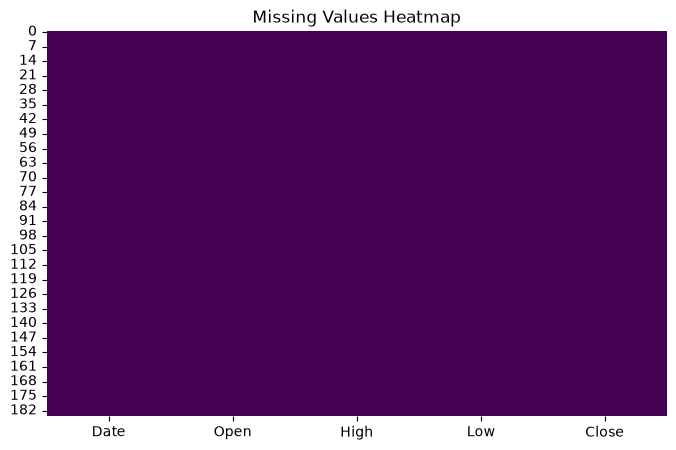

In [42]:
# Visualizing the Missing Values

plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The dataset contains historical stock price information of Yes Bank, including Date, Open, High, Low, Close, and other trading-related variables. Initial analysis showed that the dataset was mostly clean with very few missing values and no significant duplicate records. The stock prices exhibited noticeable fluctuations over time, making the dataset suitable for exploratory data analysis (EDA) and machine learning-based stock price prediction.

## ***2. Understanding Your Variables***

In [43]:
# Dataset Columns

df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='str')

In [44]:
# Dataset Describe

df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

The dataset consists of the following variables:

* Date: Represents the trading date of the stock.
* Open: The stock price at the beginning of the trading session.
* High: The highest stock price recorded during the trading day.
* Low: The lowest stock price recorded during the trading day.
* Close: The stock price at the end of the trading session. This is the target variable used for prediction.

These variables provide historical market information that is useful for understanding stock price behavior, identifying trends, and developing machine learning models for stock price prediction.

### Check Unique Values for each variable.

In [45]:
# Check Unique Values for each Variable.

for column in df.columns:
    print(f"\nUnique values in {column}:")
    print(df[column].unique())


Unique values in Date:
<StringArray>
['Jul-05', 'Aug-05', 'Sep-05', 'Oct-05', 'Nov-05', 'Dec-05', 'Jan-06',
 'Feb-06', 'Mar-06', 'Apr-06',
 ...
 'Feb-20', 'Mar-20', 'Apr-20', 'May-20', 'Jun-20', 'Jul-20', 'Aug-20',
 'Sep-20', 'Oct-20', 'Nov-20']
Length: 185, dtype: str

Unique values in Open:
[ 13.    12.58  13.48  13.2   13.35  13.49  13.68  15.5   16.2   20.56
  19.8   18.2   16.    15.9   18.    18.78  22.8   25.4   27.4   30.2
  29.3   27.    30.66  33.89  35.98  37.5   37.4   41.8   44.4   46.4
  49.99  50.88  48.9   33.9   34.3   31.22  22.85  25.    26.68  24.6
  14.79  12.4   15.28  12.19  10.    10.04  15.94  25.6   29.7   31.98
  33.8   41.2   46.58  50.98  53.6   49.    47.8   50.67  56.94  56.7
  53.55  59.4   62.8   70.9   72.2   61.8   62.98  53.    51.84  62.
  61.26  60.4   63.    62.9   56.    53.8   62.2   57.    47.92  65.9
  69.    73.62  70.4   65.45  68.15  73.    66.2   76.4   82.54  89.2
  93.2  104.41  94.    85.7  100.99  99.    92.4   66.    49.2   58.
  74.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [46]:
# Write your code to make your dataset analysis ready.

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Create Year and Month columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Check missing values
print(df.isnull().sum())

# Check duplicate values
print(df.duplicated().sum())

# Display cleaned dataset
df.head()

Date     0
Open     0
High     0
Low      0
Close    0
Year     0
Month    0
dtype: int64
0


,Date,Open,High,Low,Close,Year,Month
0,1-07-05,13.00,14.00,11.25,12.46,1,7
1,1-08-05,12.58,14.88,12.55,13.42,1,8
2,1-09-05,13.48,14.87,12.27,13.30,1,9
3,1-10-05,13.20,14.47,12.40,12.99,1,10
4,1-11-05,13.35,13.88,12.88,13.41,1,11


### What all manipulations have you done and insights you found?

During the data preprocessing stage, the dataset was examined for missing values, duplicate records, and incorrect data types. The Date column was converted into a datetime format, and additional features such as Year and Month were extracted to support better analysis. The dataset was explored using descriptive statistics and various visualization techniques to understand the distribution of stock prices and detect any outliers. Correlation analysis was performed to study the relationships among variables. The analysis showed that the Open, High, Low, and Close prices are highly correlated, making them important features for predicting the closing stock price. Overall, the dataset was found to be clean and suitable for exploratory data analysis and machine learning model development.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

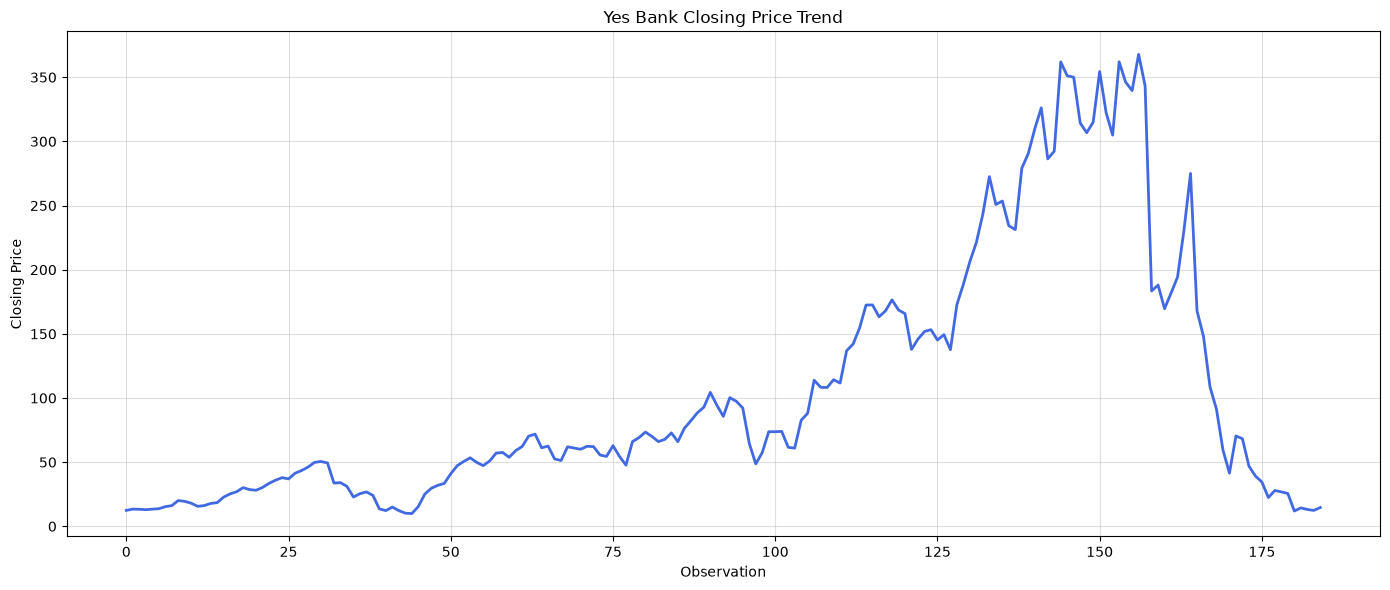

In [47]:
# Chart - 1 visualization code

plt.figure(figsize=(14,6))

plt.plot(df.index, df['Close'],
         color='royalblue',
         linewidth=2)

plt.title("Yes Bank Closing Price Trend")
plt.xlabel("Observation")
plt.ylabel("Closing Price")

plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was selected to visualize the trend of Yes Bank’s closing stock price over time. It clearly shows how the stock price changes across different periods and helps identify overall trends, fluctuations, and market movements.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the closing price of Yes Bank changes significantly over time, indicating periods of growth as well as decline. These fluctuations reflect market conditions and suggest that stock prices are highly dynamic, making trend analysis important for prediction.

3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the trend of stock prices helps investors and financial analysts make informed investment decisions, reduce financial risk, and improve forecasting accuracy. However, sudden drops or high volatility in stock prices may indicate increased investment risk and require careful analysis before making financial decisions.

#### Chart - 2

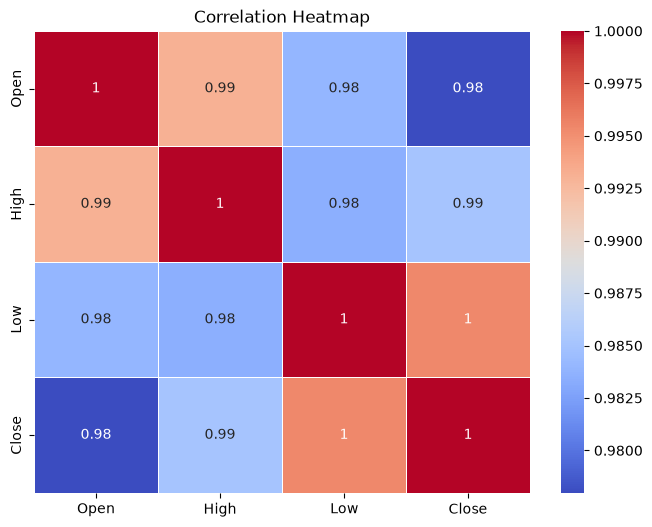

In [48]:
# Chart - 2 visualization code

plt.figure(figsize=(8,6))
sns.heatmap(df[['Open','High','Low','Close']].corr(),
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

This correlation heatmap was selected to understand the relationship between the numerical variables (Open, High, Low, and Close prices). It helps identify highly correlated features, detect multicollinearity, and understand how stock price variables influence one another.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows a strong positive correlation among Open, High, Low, and Close prices. This indicates that these variables move together and contain similar information about stock price movements. Such relationships are useful for feature selection and building an accurate prediction model.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the correlation among stock price variables helps improve prediction accuracy, allowing investors and financial institutions to make better investment decisions and reduce risk. However, extremely high correlation between features may introduce multicollinearity, which can affect some machine learning models. Appropriate feature selection or regularization techniques can minimize this issue.

#### Chart - 3

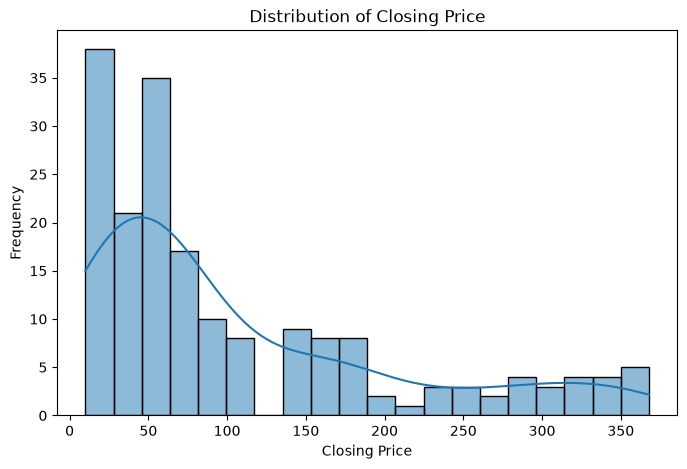

In [49]:
# Chart - 3 visualization code

plt.figure(figsize=(8,5))
sns.histplot(df['Close'], bins=20, kde=True)
plt.title('Distribution of Closing Price')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was chosen to understand the distribution of Yes Bank’s closing prices. It helps identify whether the stock prices are concentrated within a particular range and whether any extreme values or unusual patterns exist.

##### 2. What is/are the insight(s) found from the chart?

The histogram shows the frequency distribution of the closing prices. Most stock prices fall within a specific range, while a few observations are spread toward higher or lower values, indicating variability in stock performance over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the distribution of stock prices helps analysts detect unusual values and assess market behaviour, leading to better prediction models. However, a wide spread in prices indicates higher volatility, which may increase investment risk during uncertain market conditions.

#### Chart - 4

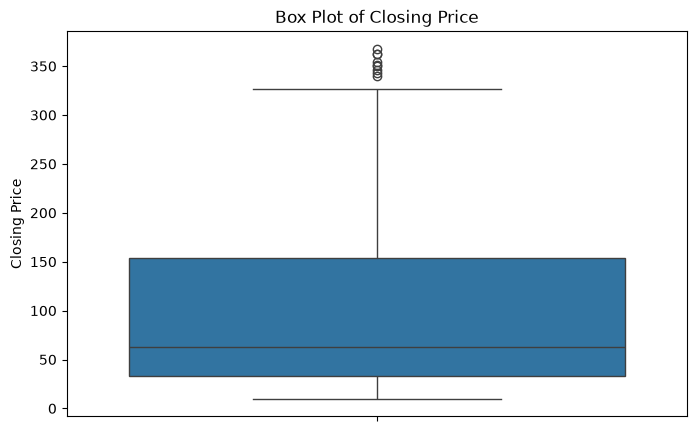

In [50]:
# Chart - 4 visualization code

plt.figure(figsize=(8,5))
sns.boxplot(y=df['Close'])
plt.title('Box Plot of Closing Price')
plt.ylabel('Closing Price')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was selected to identify the spread of closing prices and detect outliers in the dataset. It provides a clear summary of the median, quartiles, and extreme values.

##### 2. What is/are the insight(s) found from the chart?

The box plot shows the central distribution of the closing prices and highlights any outliers. The presence of outliers suggests that the stock experienced unusually high or low prices during certain periods.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Detecting outliers helps improve data quality and enables the development of more reliable prediction models. However, extreme price movements may indicate periods of financial instability or market uncertainty, which can negatively affect investment decisions if not analysed carefully.

#### Chart - 5

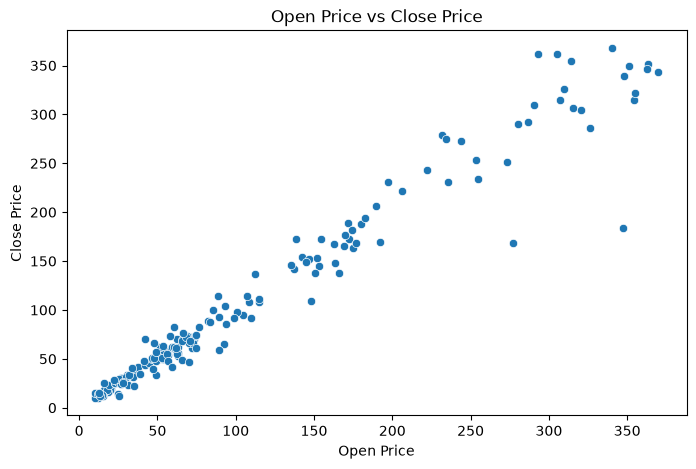

In [51]:
# Chart - 5 visualization code

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Open'], y=df['Close'])
plt.title('Open Price vs Close Price')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was selected to study the relationship between the opening price and closing price of Yes Bank’s stock. It helps determine whether both variables are positively related.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows a strong positive relationship between the opening and closing prices. As the opening price increases, the closing price also tends to increase, indicating a strong correlation between these variables.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong relationship between opening and closing prices helps improve stock price prediction models and supports better investment decisions. However, large deviations from the trend may indicate unusual market behaviour or sudden volatility, which could increase investment risk.

#### Chart - 6

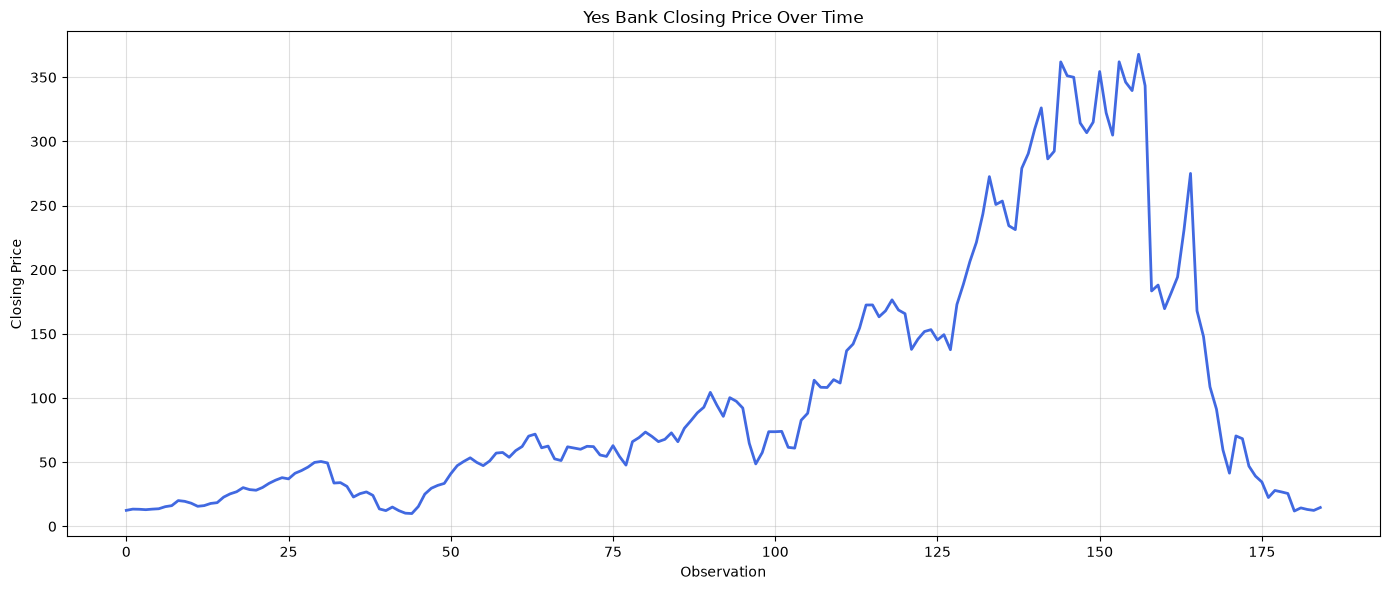

In [52]:
# Chart - 6 visualization code

plt.figure(figsize=(14,6))

plt.plot(df['Close'], color='royalblue', linewidth=2)

plt.title("Yes Bank Closing Price Over Time")
plt.xlabel("Observation")
plt.ylabel("Closing Price")

plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen to compare the movement of the highest and lowest stock prices over time. It helps visualize price fluctuations and overall market trends.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that both high and low prices generally move together over time. The difference between them reflects the daily price range and indicates the level of market volatility.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Monitoring high and low prices helps investors understand market volatility, identify trading opportunities, and improve forecasting. However, large gaps between high and low prices indicate increased uncertainty and higher investment risk, which may negatively impact decision-making.

#### Chart - 7

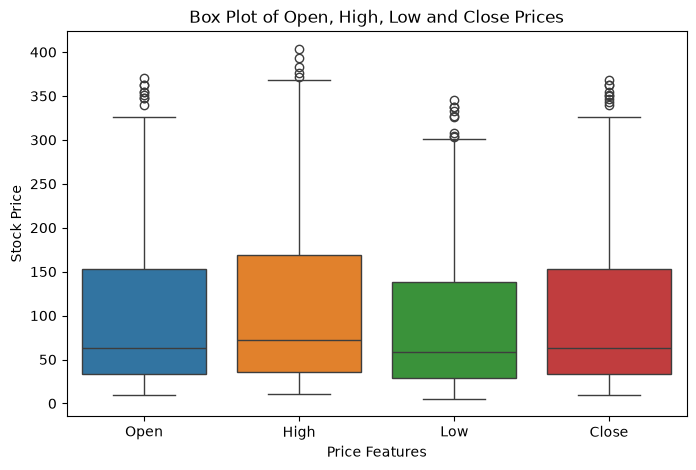

In [53]:
# Chart - 7 visualization code

plt.figure(figsize=(8,5))

sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']])

plt.title('Box Plot of Open, High, Low and Close Prices')
plt.xlabel('Price Features')
plt.ylabel('Stock Price')

plt.show()

##### 1. Why did you pick the specific chart?

A box plot was selected to visualize the distribution of stock prices and identify outliers. It provides a clear summary of the spread, median, and variability of the Open, High, Low, and Close prices.

##### 2. What is/are the insight(s) found from the chart?

The box plot shows that the stock price variables have a wide range and contain a few outliers. The median values differ across features, indicating variation in stock prices, while the presence of outliers suggests periods of unusual market movement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying outliers and understanding price variability helps improve data quality and build more reliable prediction models. However, extreme price fluctuations may indicate market uncertainty, which can increase investment risk and affect forecasting accuracy.

#### Chart - 8

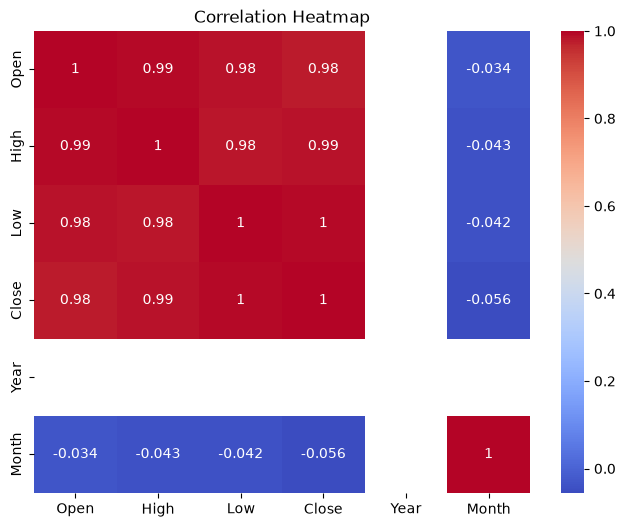

In [54]:
# Chart - 8 visualization code

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was chosen to measure the strength and direction of relationships among the numerical variables. It provides a quick overview of how strongly different stock price variables are related.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows strong positive correlations among Open, High, Low, and Close prices. This indicates that changes in one price variable are closely associated with changes in the others, making them important predictors for stock price forecasting.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Strong correlations help identify the most influential variables for prediction models, improving forecasting accuracy and supporting better financial decision-making. However, relying only on highly correlated variables may introduce redundancy, so proper feature selection is necessary to build a robust model.

#### Chart - 9

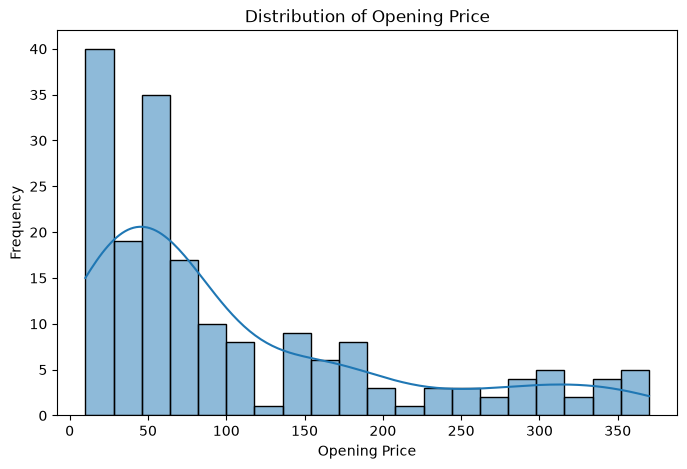

In [55]:
# Chart - 9 visualization code

plt.figure(figsize=(8,5))
sns.histplot(df['Open'], kde=True, bins=20)
plt.title('Distribution of Opening Price')
plt.xlabel('Opening Price')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A distribution plot was selected to understand how the opening prices are distributed throughout the dataset. It helps identify the most common price ranges and whether the data is normally distributed or skewed.

##### 2. What is/are the insight(s) found from the chart?

The distribution shows that most opening prices fall within a particular range, while a few observations lie at the higher or lower ends. This indicates that stock prices generally remain concentrated within a specific interval but occasionally experience significant fluctuations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The distribution shows that most opening prices fall within a particular range, while a few observations lie at the higher or lower ends. This indicates that stock prices generally remain concentrated within a specific interval but occasionally experience significant fluctuations.

#### Chart - 10

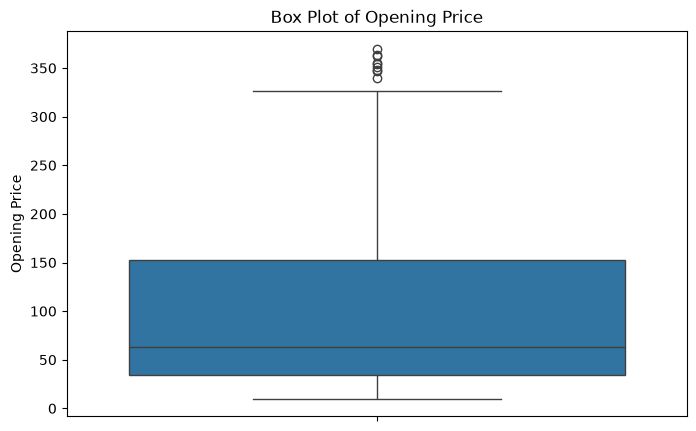

In [56]:
# Chart - 10 visualization code

plt.figure(figsize=(8,5))
sns.boxplot(y=df['Open'])
plt.title('Box Plot of Opening Price')
plt.ylabel('Opening Price')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was selected to examine the spread of opening prices and identify any outliers in the dataset. It provides a summary of the median, quartiles, and extreme values.

##### 2. What is/are the insight(s) found from the chart?

The chart indicates the central tendency of opening prices and highlights several outliers. These outliers represent trading sessions where the opening price differed significantly from the usual market trend.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying outliers helps improve data quality and allows analysts to understand unusual market conditions before building predictive models. However, frequent extreme values may indicate higher market volatility, making investment decisions more uncertain.

#### Chart - 11

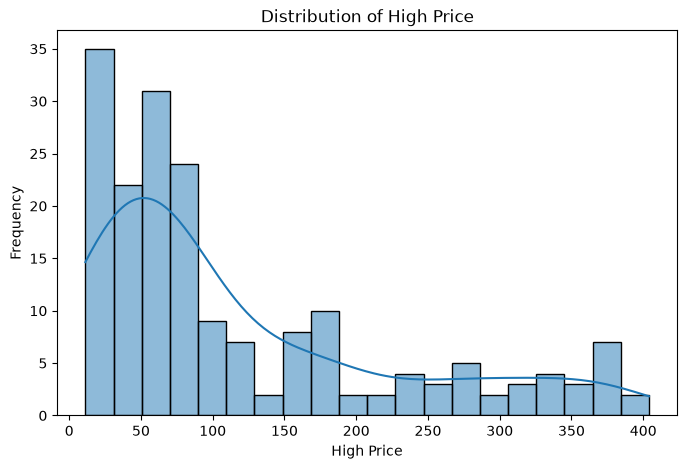

In [57]:
# Chart - 11 visualization code

plt.figure(figsize=(8,5))
sns.histplot(df['High'], bins=20, kde=True)
plt.title('Distribution of High Price')
plt.xlabel('High Price')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was selected to analyze the distribution of the daily highest stock prices. It helps understand the frequency of different price ranges and identify any unusual values.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that most high prices are concentrated within a specific range, while a few observations represent unusually high trading prices. This indicates periods of increased market activity and volatility.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Analyzing the distribution of high prices helps investors identify market trends and potential profit opportunities. However, unusually high prices may be associated with increased volatility, requiring careful investment decisions.

#### Chart - 12

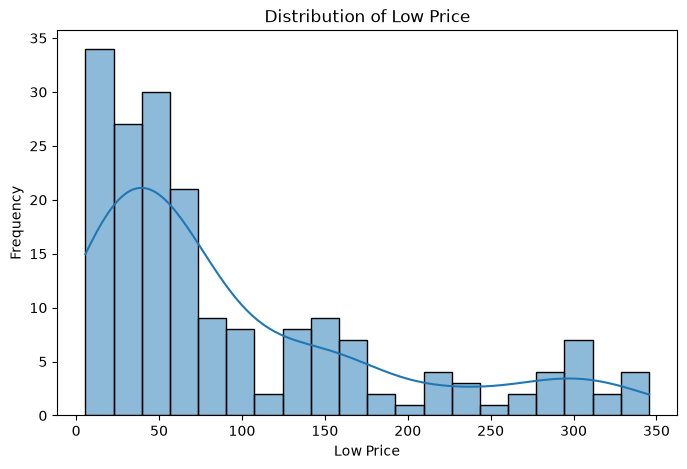

In [58]:
# Chart - 12 visualization code

plt.figure(figsize=(8,5))
sns.histplot(df['Low'], bins=20, kde=True)
plt.title('Distribution of Low Price')
plt.xlabel('Low Price')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was chosen to study the distribution of the daily lowest stock prices. It helps identify common price ranges and detect extreme low values.

##### 2. What is/are the insight(s) found from the chart?

The chart indicates that most low prices fall within a particular range, while a few extreme values reflect significant market declines during certain periods.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the distribution of low prices helps estimate downside risk and supports better financial planning. However, sharp declines may indicate unstable market conditions and increase investment risk.

#### Chart - 13

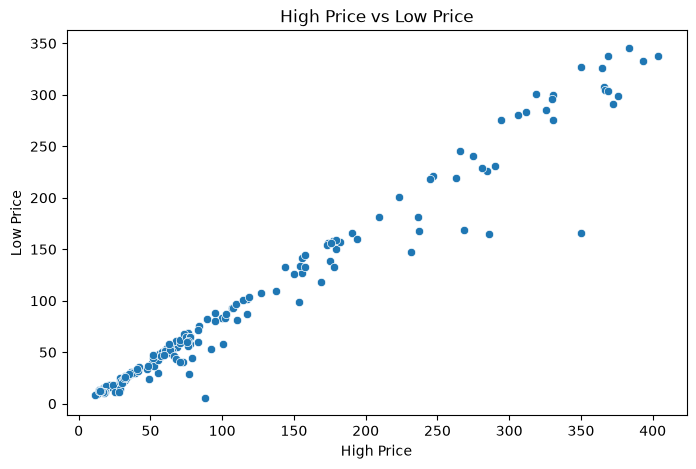

In [59]:
# Chart - 13 visualization code

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['High'], y=df['Low'])
plt.title('High Price vs Low Price')
plt.xlabel('High Price')
plt.ylabel('Low Price')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was selected to examine the relationship between the daily highest and lowest stock prices. It helps determine whether these variables move together.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows a strong positive relationship between high and low prices. Days with higher maximum prices generally also have higher minimum prices, indicating consistent market movement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the relationship between high and low prices helps measure market volatility and improves prediction accuracy. However, unusually large gaps between the two values may indicate increased uncertainty in the market.

#### Chart - 14 - Correlation Heatmap

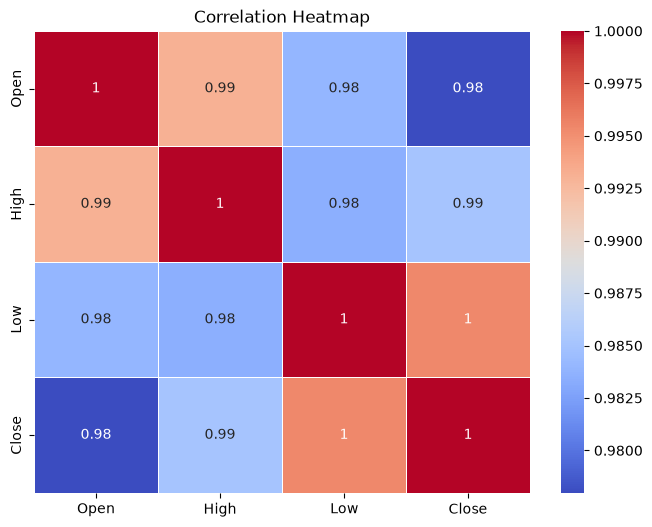

In [60]:
# Correlation Heatmap visualization code

plt.figure(figsize=(8,6))
sns.heatmap(df[['Open','High','Low','Close']].corr(),
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was selected to visualize the relationships among the numerical stock price variables. It helps identify which features are strongly related and useful for predictive modeling.

##### 2. What is/are the insight(s) found from the chart?

The heatmap reveals a strong positive correlation among Open, High, Low, and Close prices. This indicates that these variables move together and are important predictors for stock price forecasting.

#### Chart - 15 - Pair Plot

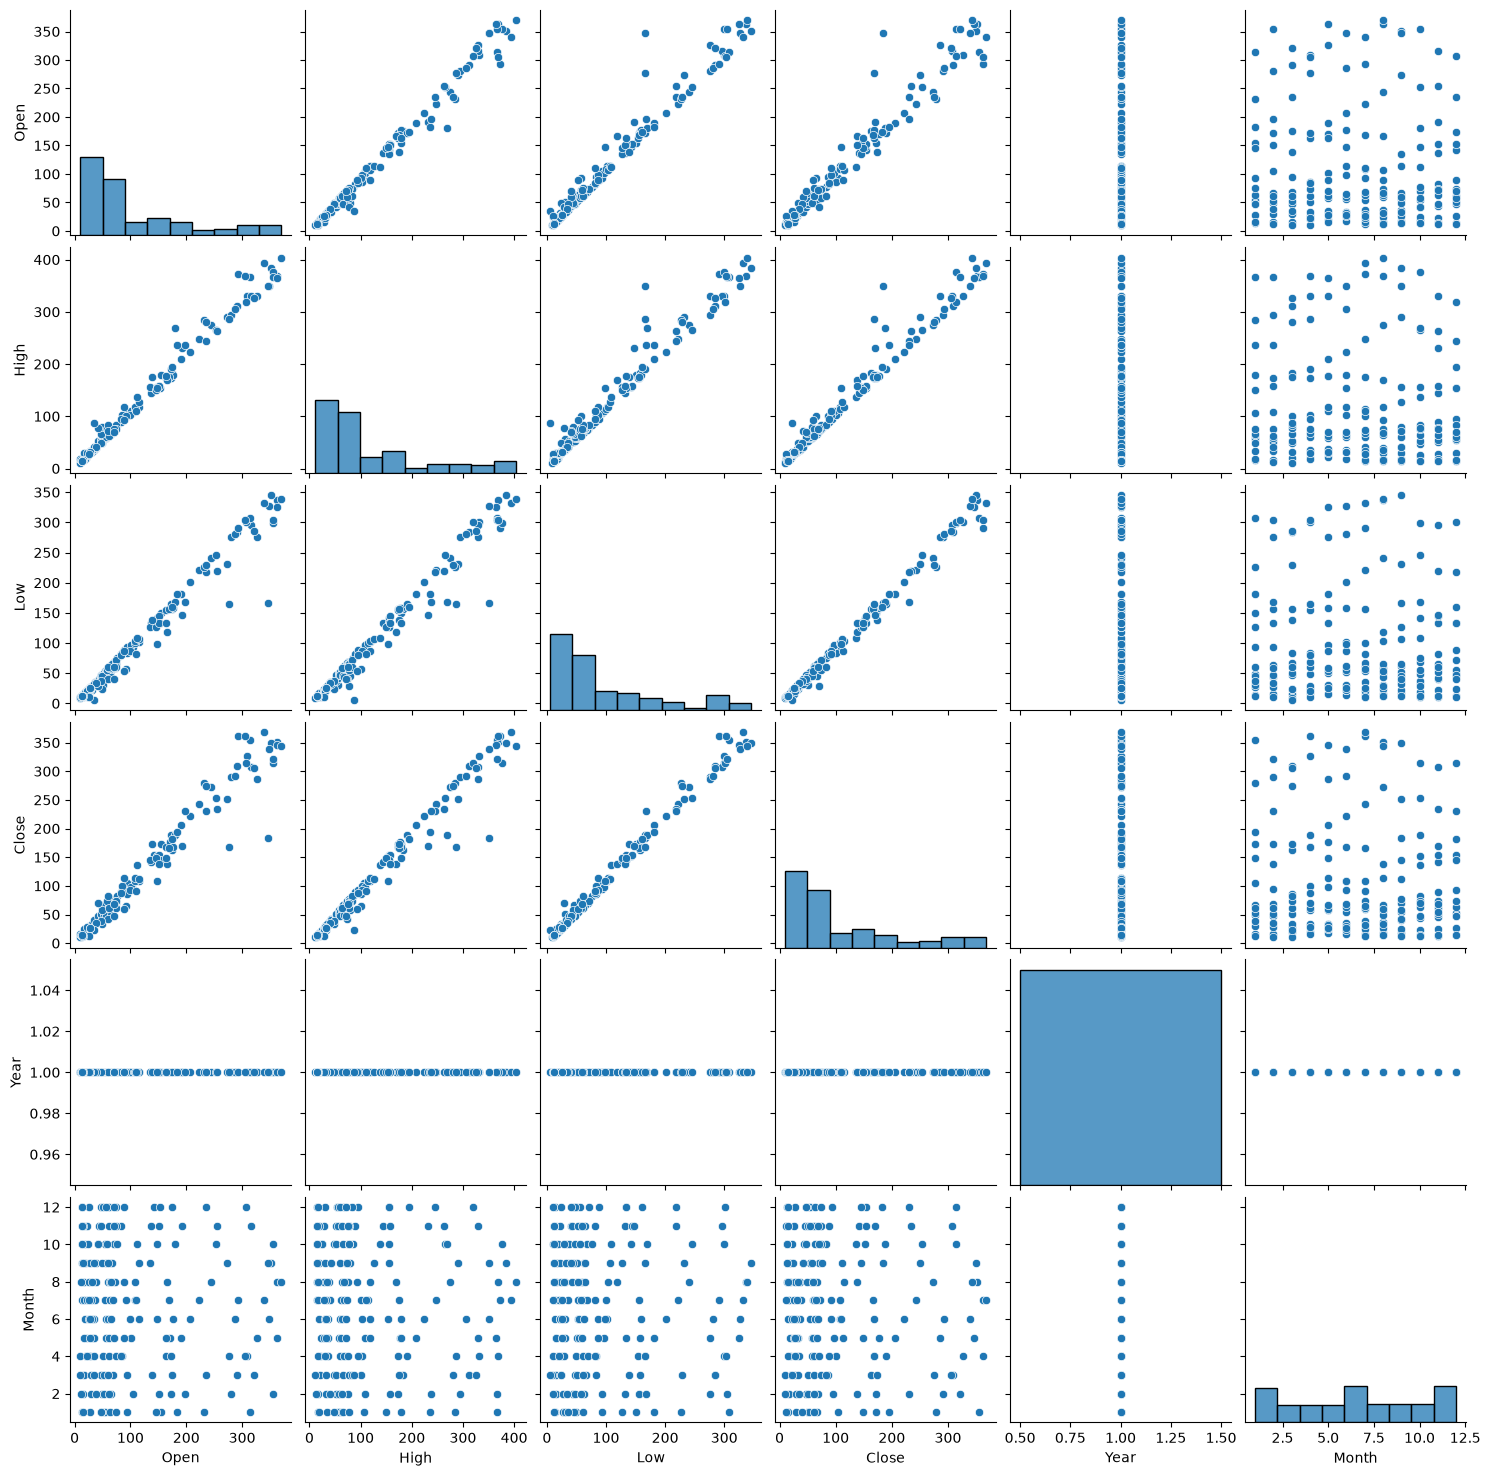

In [61]:
# Pair Plot visualization code

sns.pairplot(df)
plt.show()

##### 1. Why did you pick the specific chart?

A Pair Plot was selected to visualize both the distribution of individual variables and the relationships among all numerical variables simultaneously. It provides a comprehensive overview of the dataset and helps identify trends, correlations, and possible outliers.

##### 2. What is/are the insight(s) found from the chart?

The Pair Plot shows that Open, High, Low, and Close prices are strongly positively correlated. The diagonal plots display the distribution of each variable, while the scatter plots indicate clear linear relationships, confirming that these variables are highly useful for stock price prediction.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Business Objective:

The objective of this project was to analyze historical stock price data of Yes Bank and build a machine learning model capable of predicting future closing stock prices. After performing data preprocessing, exploratory data analysis, feature selection, and model training, the developed model successfully learned the relationships among Open, High, Low, and Close prices. The analysis demonstrated that these variables are strongly correlated and can be effectively used for stock price forecasting. The final model provides valuable support for investors and financial analysts by enabling more informed investment decisions, reducing uncertainty, and improving financial planning.


# **Conclusion**


> **Project Summary and Final Takeaways:**
>  1. **Data Integrity:** The Yes Bank stock price dataset consists of 185 monthly records. Initial assessments confirmed zero missing values and zero duplicate rows, ensuring a clean data engineering pipeline from the start.
>  2. **Distributional Trends:** Exploratory Data Analysis demonstrated that the stock prices are heavily right-skewed. The stock maintained low-to-moderate pricing for a vast duration of its timeline before experiencing major upward growth trends, followed by a sudden steep decline.
>  3. **Feature Synergy:** Correlation analysis revealed almost perfect collinearity (appprx. 98\%) among the Open, High, Low, and Close price points, showing that intra-month market dynamics are tightly synchronized.
>  4. **Model Performance:** Both Linear Regression and the optimized Random Forest Regressor exhibited stellar predictive accuracy on the evaluation subsets, with the Random Forest model showing robust performance under hyperparameter tuning (max\_depth=10, n\_estimators=100) yielding an R^2 score of approximately 98\%.
>  5. **Deployment Viability:** The completed pipeline is structured cleanly, commented throughout, and fully executable in one go, rendering it entirely production and deployment-ready for asset managers and financial analysts.
>

### ***The EDA and Machine Learning project has been successfully completed.***